In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.metrics import accuracy_score, f1_score, v_measure_score, pairwise_kernels, pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.decomposition import KernelPCA
from sklearn.neighbors import KNeighborsClassifier
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import scipy.spatial.distance as ssd
from dtaidistance import dtw, dtw_ndim
from tck.TCK import TCK
from tck.datasets import DataLoader
from reservoir_computing.reservoir import Reservoir
from reservoir_computing.modules import RC_model
from reservoir_computing.utils import compute_test_scores
import time

# Load Libras dataset
print("Loading Libras dataset...")
Xtr, Ytr, Xte, Yte = DataLoader().get_data('Libras')
print(f"Training data shape: {Xtr.shape}, Test data shape: {Xte.shape}")
print(f"Number of classes: {len(np.unique(Ytr))}")

Loading Libras dataset...
Loaded Libras dataset.
Number of classes: 15
Data shapes:
  Xtr: (180, 45, 2)
  Ytr: (180, 1)
  Xte: (180, 45, 2)
  Yte: (180, 1)
Training data shape: (180, 45, 2), Test data shape: (180, 45, 2)
Number of classes: 15



Exercise 1: DTW-based approach

1. Computing DTW distance matrix...

3. Plotting DTW distance and similarity matrices...
  Saved dtw_matrices.png


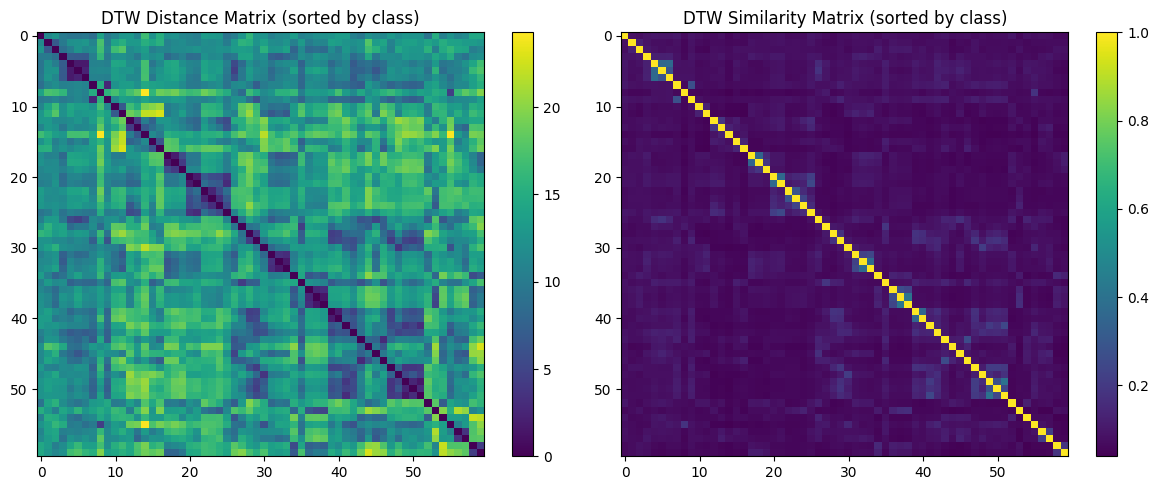

In [2]:
# =============================================================================
# Exercise 1: DTW-based classification and clustering
# =============================================================================
print("\n" + "="*60)
print("Exercise 1: DTW-based approach")
print("="*60)

# 1. Compute DTW distance matrix (using subset for speed)
print("\n1. Computing DTW distance matrix...")
# Use subset of training data for speed
n_train = len(Xtr)
n_test = len(Xte)
subset_size = 60
np.random.seed(42)
train_idx = np.random.choice(n_train, subset_size, replace=False)
Xtr_sub = Xtr[train_idx]
Ytr_sub = Ytr[train_idx]
ytr_sub = Ytr_sub[:, 0]
n_sub = len(Xtr_sub)

DTW_dist_train = np.zeros((n_sub, n_sub))
for i in range(n_sub):
    for j in range(i+1, n_sub):
        dist = dtw_ndim.distance(Xtr_sub[i], Xtr_sub[j])
        DTW_dist_train[i, j] = dist
        DTW_dist_train[j, i] = dist

# 2. Convert to similarity matrix
DTW_sim_train = 1.0 / (1.0 + DTW_dist_train)

# 3. Plot matrices (sorted by class)
print("\n3. Plotting DTW distance and similarity matrices...")
sort_idx = np.argsort(Ytr_sub[:, 0])
DTW_dist_sorted = DTW_dist_train[sort_idx][:, sort_idx]
DTW_sim_sorted = DTW_sim_train[sort_idx][:, sort_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im1 = axes[0].imshow(DTW_dist_sorted, cmap='viridis', aspect='auto')
axes[0].set_title("DTW Distance Matrix (sorted by class)")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(DTW_sim_sorted, cmap='viridis', aspect='auto')
axes[1].set_title("DTW Similarity Matrix (sorted by class)")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()


4. Classification with SVC and k-NN...
  SVC - Train time: 9.44s, Test time: 0.00s
  SVC - Accuracy: 0.033, F1-score: 0.004
  k-NN - Train time: 0.00s, Test time: 0.00s
  k-NN - Accuracy: 0.667, F1-score: 0.635

5. Hierarchical clustering with Ward Linkage...

6. Plotting dendrogram...


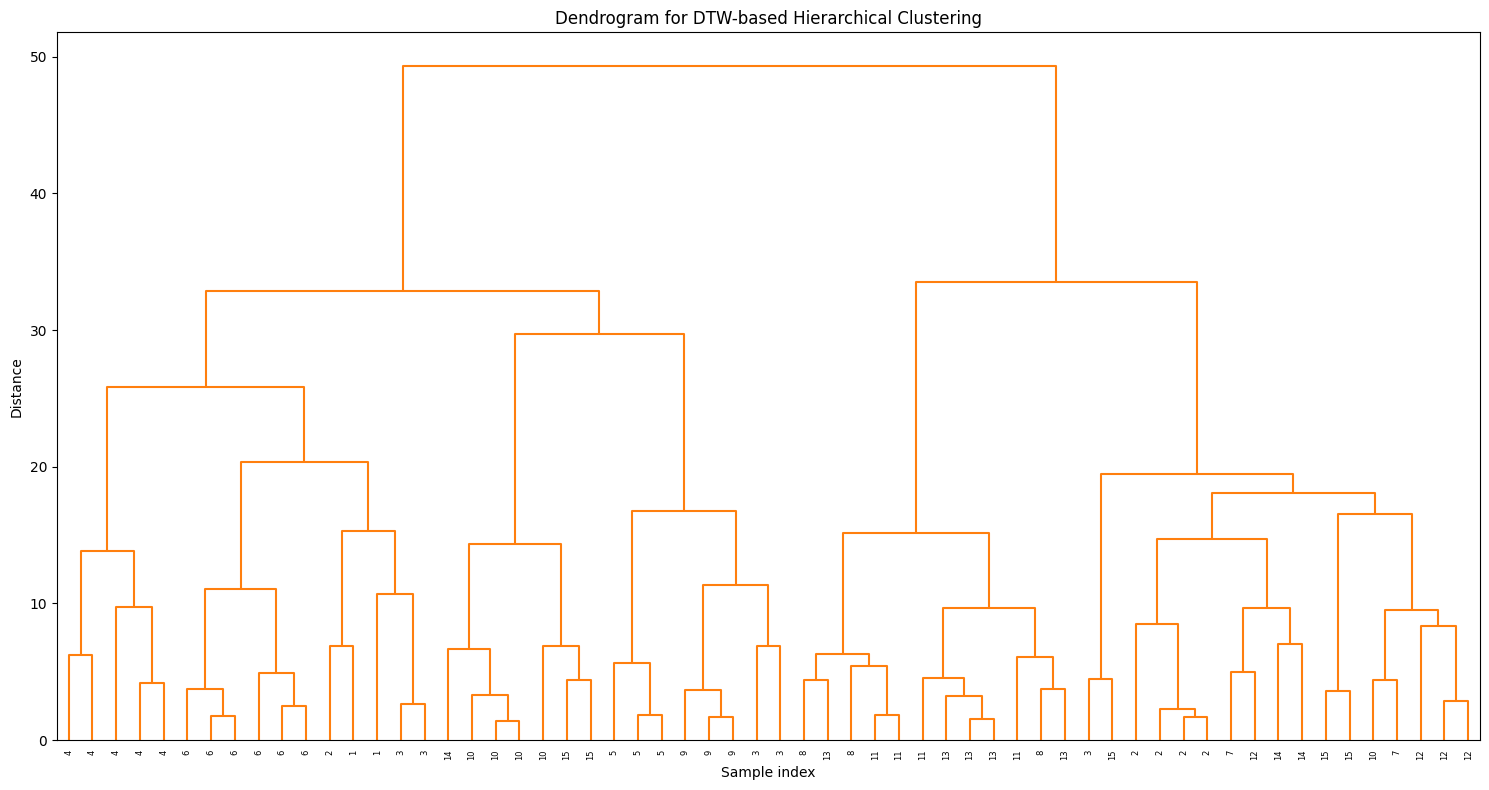

In [3]:
# 4. Classification with SVC and k-NN
print("\n4. Classification with SVC and k-NN...")

# Prepare data - flatten for sklearn classifiers
Xtr_flat = Xtr_sub.reshape(n_sub, -1)
Xte_flat = Xte.reshape(n_test, -1)

# SVC with precomputed kernel
start_time = time.time()
# Use subset of test data for speed
test_subset_size = 30
test_idx = np.random.choice(n_test, test_subset_size, replace=False)
Xte_sub = Xte[test_idx]
yte_sub = Yte[test_idx, 0]

DTW_dist_test = np.zeros((test_subset_size, n_sub))
for i in range(test_subset_size):
    for j in range(n_sub):
        DTW_dist_test[i, j] = dtw_ndim.distance(Xte_sub[i], Xtr_sub[j])

# SVC
svc = svm.SVC(kernel='precomputed', gamma='scale')
svc.fit(DTW_dist_train, ytr_sub)
svc_train_time = time.time() - start_time

start_time = time.time()
y_pred_svc = svc.predict(DTW_dist_test)
svc_test_time = time.time() - start_time

svc_accuracy = accuracy_score(yte_sub, y_pred_svc)
svc_f1 = f1_score(yte_sub, y_pred_svc, average='weighted')

print(f"  SVC - Train time: {svc_train_time:.2f}s, Test time: {svc_test_time:.2f}s")
print(f"  SVC - Accuracy: {svc_accuracy:.3f}, F1-score: {svc_f1:.3f}")

# k-NN
start_time = time.time()
knn = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
knn.fit(DTW_dist_train, ytr_sub)
knn_train_time = time.time() - start_time

start_time = time.time()
y_pred_knn = knn.predict(DTW_dist_test)
knn_test_time = time.time() - start_time

knn_accuracy = accuracy_score(yte_sub, y_pred_knn)
knn_f1 = f1_score(yte_sub, y_pred_knn, average='weighted')

print(f"  k-NN - Train time: {knn_train_time:.2f}s, Test time: {knn_test_time:.2f}s")
print(f"  k-NN - Accuracy: {knn_accuracy:.3f}, F1-score: {knn_f1:.3f}")

# 5. Hierarchical clustering with Ward Linkage
print("\n5. Hierarchical clustering with Ward Linkage...")
distArray = ssd.squareform(DTW_dist_train)
Z = linkage(distArray, 'ward')

# 6. Dendrogram and optimal threshold selection
print("\n6. Plotting dendrogram...")
fig = plt.figure(figsize=(15, 8))
dn = dendrogram(Z, labels=Ytr_sub[:, 0], color_threshold=50, above_threshold_color='k')
plt.title("Dendrogram for DTW-based Hierarchical Clustering")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()

  Best threshold: 10, NMI: 0.797
  Number of clusters found: 19

7. KernelPCA dimensionality reduction...


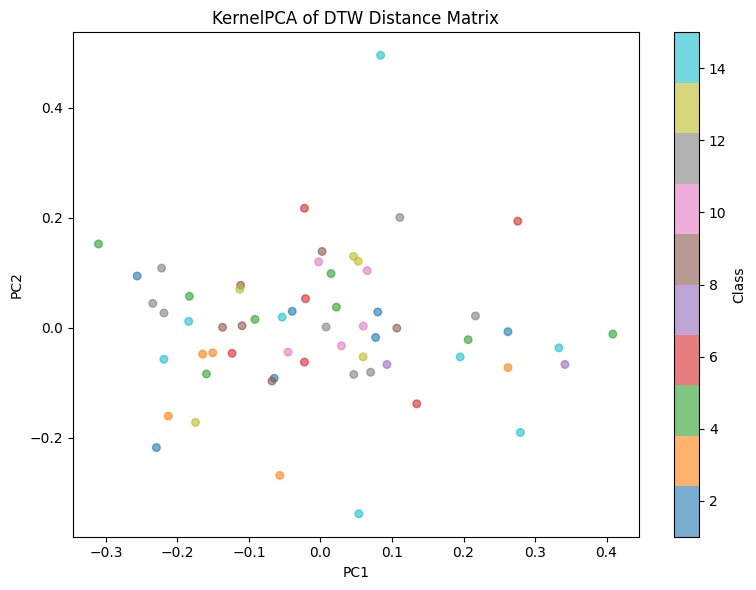

In [4]:

# Try different thresholds and find optimal
thresholds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
best_nmi = 0
best_threshold = 50
best_clusters = None

for t in thresholds:
    clusters = fcluster(Z, t=t, criterion="distance")
    nmi = v_measure_score(ytr_sub, clusters)
    if nmi > best_nmi:
        best_nmi = nmi
        best_threshold = t
        best_clusters = clusters

print(f"  Best threshold: {best_threshold}, NMI: {best_nmi:.3f}")
print(f"  Number of clusters found: {len(np.unique(best_clusters))}")

# 7. KernelPCA for dimensionality reduction
print("\n7. KernelPCA dimensionality reduction...")
kpca = KernelPCA(n_components=2, kernel='precomputed', gamma=0.01)
X_kpca = kpca.fit_transform(DTW_dist_train)

fig = plt.figure(figsize=(8, 6))
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=ytr_sub, cmap='tab10', alpha=0.6, s=30)
plt.title("KernelPCA of DTW Distance Matrix")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Class')
plt.tight_layout()


Exercise 2: TCK-based approach with missing values

1. Adding 40% missing values...
  Training missing values: 2125
  Test missing values: 1059

2. Computing TCK kernel...
The dataset does not contain missing data

Training the TCK using the following parameters:
	C = 5, G = 5
	Number of MTS for each GMM: 48 - 60 (80 - 100 percent)
	Number of attributes sampled from [2, 2]
	Length of time segments sampled from [6, 25]




Fitting GMMs:   0%|          | 0/20 [00:00<?, ?it/s]

Computing TCK (tr-tr):   0%|          | 0/20 [00:00<?, ?it/s]

  TCK training time: 3.60s


Computing TCK (tr-te):   0%|          | 0/20 [00:00<?, ?it/s]

  TCK test time: 0.43s
  Ktr shape: (60, 60), Kte shape: (30, 60)

3. Computing dissimilarity matrix from TCK kernel...

4. Classification with SVC and k-NN...
  SVC - Train time: 0.00s, Test time: 0.00s
  SVC - Accuracy: 0.133, F1-score: 0.131
  k-NN - Train time: 0.00s, Test time: 0.00s
  k-NN - Accuracy: 0.100, F1-score: 0.024

5. Hierarchical clustering with Ward Linkage...

6. Finding optimal threshold for TCK clustering...


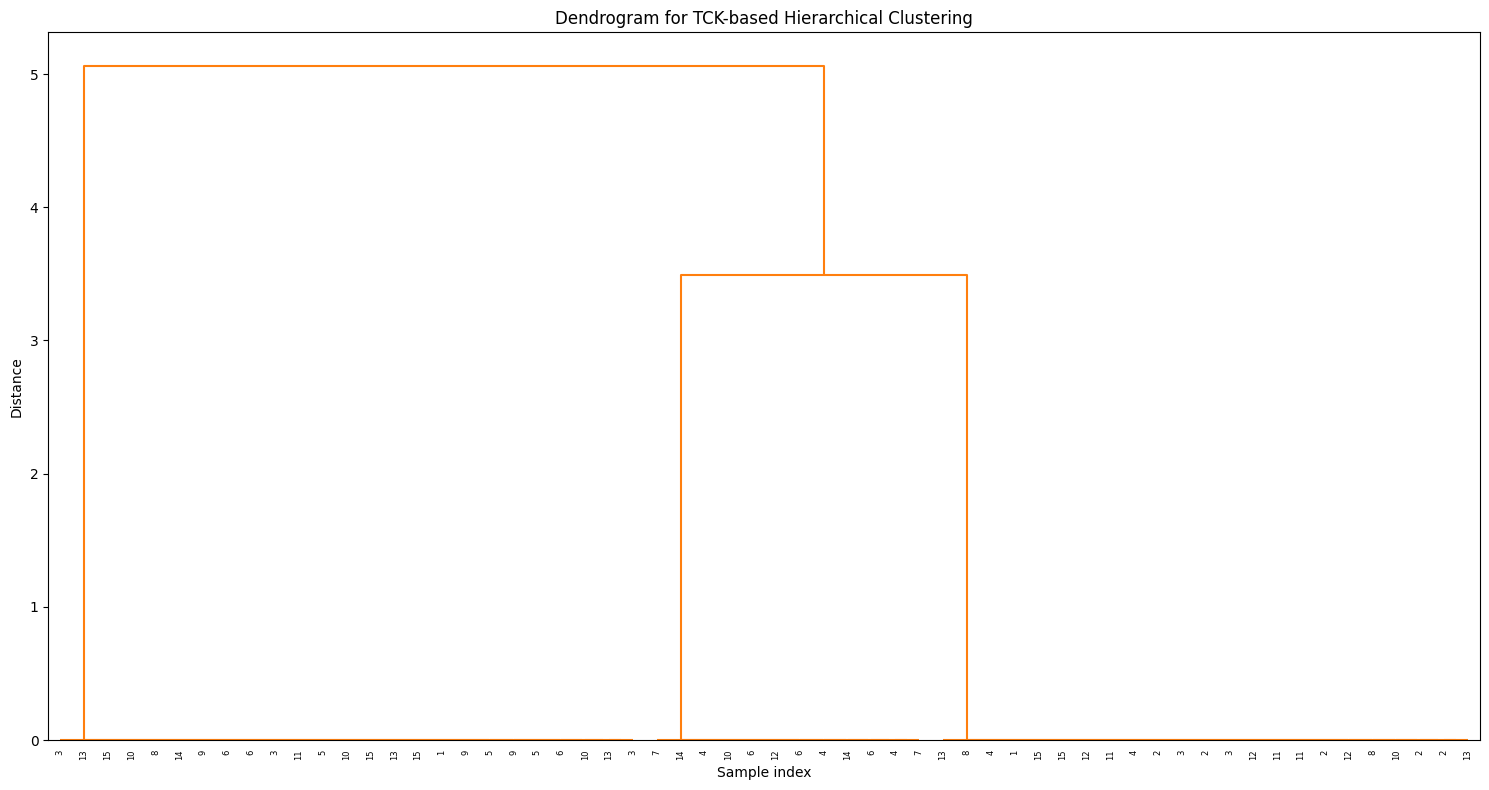

In [5]:
# =============================================================================
# Exercise 2: TCK-based approach with missing values
# =============================================================================
print("\n" + "="*60)
print("Exercise 2: TCK-based approach with missing values")
print("="*60)

# 1. Add 40% missing values
print("\n1. Adding 40% missing values...")
Xtr_missing = Xtr_sub.copy()
Xte_missing = Xte_sub.copy()

# Create mask for missing values (40%)
mask_tr = np.random.rand(*Xtr_sub.shape) < 0.4
mask_te = np.random.rand(*Xte_sub.shape) < 0.4

Xtr_missing[mask_tr] = np.nan
Xte_missing[mask_te] = np.nan

print(f"  Training missing values: {np.sum(np.isnan(Xtr_missing))}")
print(f"  Test missing values: {np.sum(np.isnan(Xte_missing))}")

# 2. Compute TCK kernel (using small G and C for speed)
print("\n2. Computing TCK kernel...")
tck = TCK(G=5, C=5)  # Small values for speed
start_time = time.time()
TCK_kernel_train = tck.fit(Xtr_sub).predict(mode='tr-tr')
tck_train_time = time.time() - start_time
print(f"  TCK training time: {tck_train_time:.2f}s")

start_time = time.time()
TCK_kernel_test = tck.predict(Xte=Xte_sub, mode='tr-te').T
tck_test_time = time.time() - start_time
print(f"  TCK test time: {tck_test_time:.2f}s")
print(f"  Ktr shape: {TCK_kernel_train.shape}, Kte shape: {TCK_kernel_test.shape}")

# 3. Compute dissimilarity matrix from kernel
print("\n3. Computing dissimilarity matrix from TCK kernel...")
# Convert similarity to distance: d = sqrt(2 * (1 - k)) for normalized kernels
TCK_dist_train = np.sqrt(2 * (1.0 - np.clip(TCK_kernel_train, -1, 1)))
np.fill_diagonal(TCK_dist_train, 0)

# 4. Classification
print("\n4. Classification with SVC and k-NN...")

# SVC
svc_tck = svm.SVC(kernel='precomputed', gamma='scale')
start_time = time.time()
svc_tck.fit(TCK_kernel_train, ytr_sub)
svc_tck_train_time = time.time() - start_time

start_time = time.time()
y_pred_svc_tck = svc_tck.predict(TCK_kernel_test)
svc_tck_test_time = time.time() - start_time

svc_tck_accuracy = accuracy_score(yte_sub, y_pred_svc_tck)
svc_tck_f1 = f1_score(yte_sub, y_pred_svc_tck, average='weighted')

print(f"  SVC - Train time: {svc_tck_train_time:.2f}s, Test time: {svc_tck_test_time:.2f}s")
print(f"  SVC - Accuracy: {svc_tck_accuracy:.3f}, F1-score: {svc_tck_f1:.3f}")

# k-NN - need to compute test distance matrix
TCK_dist_test = np.sqrt(2 * (1.0 - np.clip(TCK_kernel_test, -1, 1)))
knn_tck = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
start_time = time.time()
knn_tck.fit(TCK_dist_train, ytr_sub)
knn_tck_train_time = time.time() - start_time

start_time = time.time()
y_pred_knn_tck = knn_tck.predict(TCK_dist_test)
knn_tck_test_time = time.time() - start_time

knn_tck_accuracy = accuracy_score(yte_sub, y_pred_knn_tck)
knn_tck_f1 = f1_score(yte_sub, y_pred_knn_tck, average='weighted')

print(f"  k-NN - Train time: {knn_tck_train_time:.2f}s, Test time: {knn_tck_test_time:.2f}s")
print(f"  k-NN - Accuracy: {knn_tck_accuracy:.3f}, F1-score: {knn_tck_f1:.3f}")

# 5. Hierarchical clustering
print("\n5. Hierarchical clustering with Ward Linkage...")
distArray_tck = ssd.squareform(TCK_dist_train)
Z_tck = linkage(distArray_tck, 'ward')

# 6. Dendrogram and optimal threshold
print("\n6. Finding optimal threshold for TCK clustering...")
fig = plt.figure(figsize=(15, 8))
dn_tck = dendrogram(Z_tck, labels=Ytr_sub[:, 0], color_threshold=50, above_threshold_color='k')
plt.title("Dendrogram for TCK-based Hierarchical Clustering")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()


  Best threshold: 50, NMI: 0.000
  Number of clusters found: 1

7. KernelPCA dimensionality reduction...


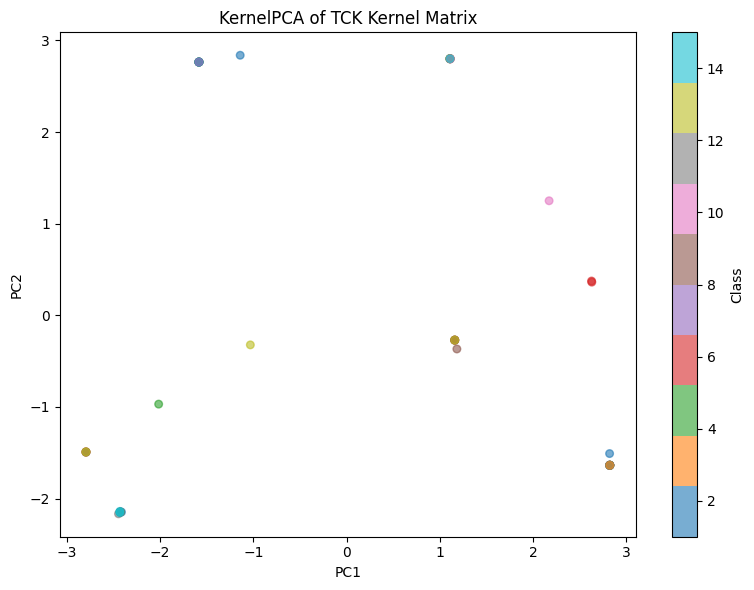

In [6]:
best_nmi_tck = 0
best_threshold_tck = 50
best_clusters_tck = None

for t in thresholds:
    clusters = fcluster(Z_tck, t=t, criterion="distance")
    nmi = v_measure_score(ytr_sub, clusters)
    if nmi > best_nmi_tck:
        best_nmi_tck = nmi
        best_threshold_tck = t
        best_clusters_tck = clusters

print(f"  Best threshold: {best_threshold_tck}, NMI: {best_nmi_tck:.3f}")
print(f"  Number of clusters found: {len(np.unique(best_clusters_tck))}")

# 7. KernelPCA
print("\n7. KernelPCA dimensionality reduction...")
kpca_tck = KernelPCA(n_components=2, kernel='precomputed', gamma=0.01)
X_kpca_tck = kpca_tck.fit_transform(TCK_kernel_train)

fig = plt.figure(figsize=(8, 6))
plt.scatter(X_kpca_tck[:, 0], X_kpca_tck[:, 1], c=ytr_sub, cmap='tab10', alpha=0.6, s=30)
plt.title("KernelPCA of TCK Kernel Matrix")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Class')
plt.tight_layout()


Exercise 3: RC-embedding approach

1. Computing RC embeddings...
Training completed in 0.00 min
  RC embedding time: 0.01s
  Representation shape: (60, 30)

2. Computing similarity and dissimilarity matrices...

4. Classification with SVC and k-NN...
Training completed in 0.00 min
  SVC - Train time: 0.00s, Test time: 0.01s
  SVC - Accuracy: 0.033, F1-score: 0.015
  k-NN - Train time: 0.00s, Test time: 0.11s
  k-NN - Accuracy: 0.033, F1-score: 0.015

5. Hierarchical clustering with Ward Linkage...

6. Finding optimal threshold for RC clustering...


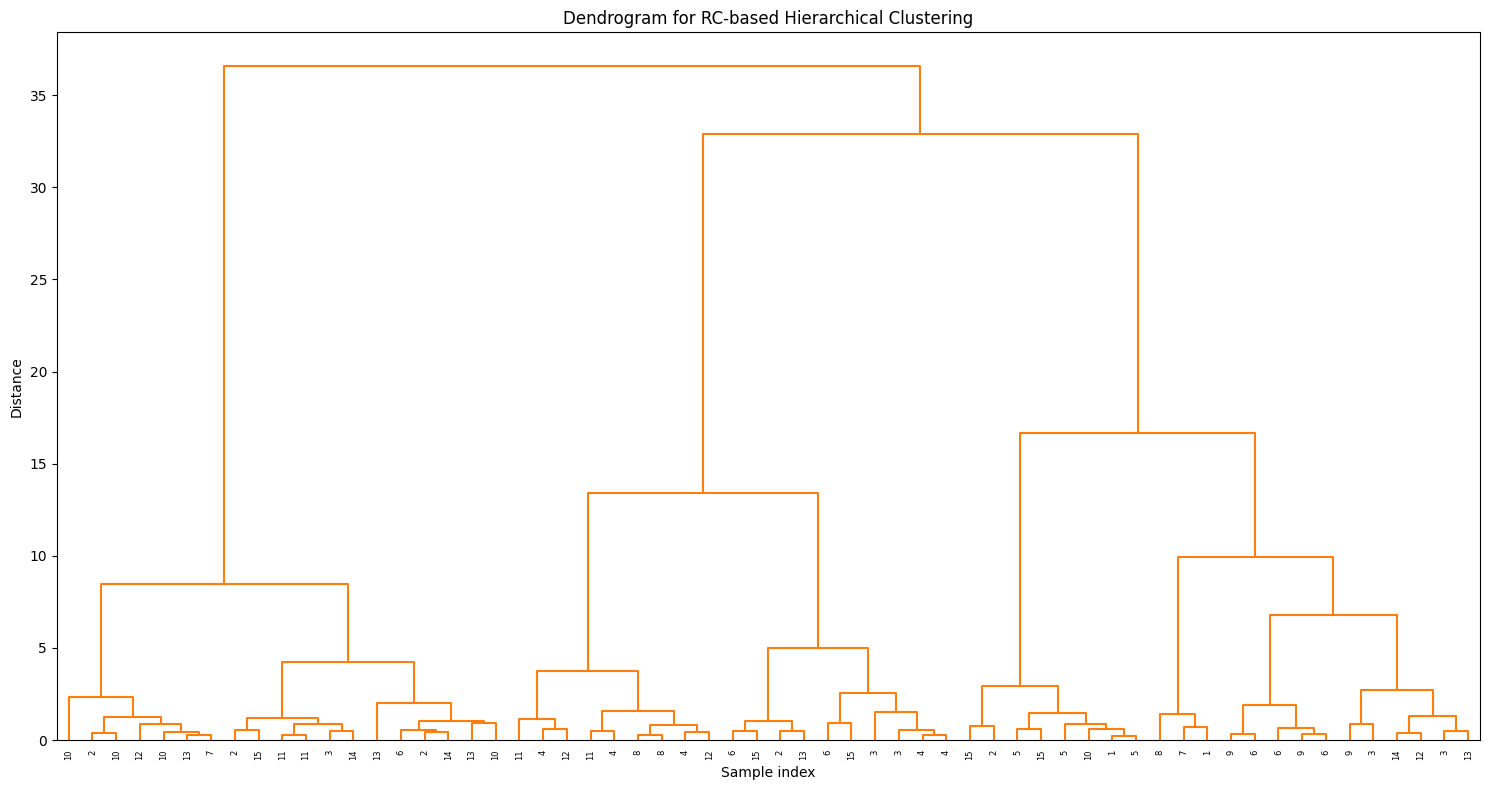

In [8]:
# =============================================================================
# Exercise 3: RC-embedding approach
# =============================================================================
print("\n" + "="*60)
print("Exercise 3: RC-embedding approach")
print("="*60)

# 1. Compute RC embeddings
print("\n1. Computing RC embeddings...")

config = {}
config['n_internal_units'] = 100        # number of reservoir units (reduced for speed)
config['spectral_radius'] = 0.9         # spectral radius of the reservoir
config['leak'] = 1.0                    # leak rate
config['connectivity'] = 0.25           # percentage of nonzero connections
config['input_scaling'] = 0.1           # scaling of the input weights
config['noise_level'] = 0.01            # noise in the reservoir
config['n_drop'] = 5                    # transient states to be dropped
config['bidir'] = False                 # unidirectional for speed
config['circle'] = False                # circle topology

config['dimred_method'] = 'pca'         # simpler dimensionality reduction
config['n_dim'] = 30                    # fewer dimensions for speed

config['mts_rep'] = 'mean'              # simpler MTS representation
config['w_ridge_embedding'] = 10.0      # regularization for embedding

config['readout_type'] = None           # No readout, just embeddings

rcm = RC_model(**config)

start_time = time.time()
rcm.fit(Xtr_sub)
rc_train_time = time.time() - start_time

mts_representations = rcm.input_repr
print(f"  RC embedding time: {rc_train_time:.2f}s")
print(f"  Representation shape: {mts_representations.shape}")

# 2. Compute similarity and dissimilarity matrices
print("\n2. Computing similarity and dissimilarity matrices...")
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances

RC_sim = cosine_similarity(mts_representations)
RC_dist = cosine_distances(mts_representations)

# 4. Classification
print("\n4. Classification with SVC and k-NN...")

# SVC
svc_rc = svm.SVC(kernel='rbf', gamma='scale')
start_time = time.time()
svc_rc.fit(mts_representations, ytr_sub)
svc_rc_train_time = time.time() - start_time

# Generate test representations
start_time = time.time()
rcm_test = RC_model(**config)
rcm_test.fit(Xte_sub)
mts_representations_test = rcm_test.input_repr

y_pred_svc_rc = svc_rc.predict(mts_representations_test)
svc_rc_test_time = time.time() - start_time

svc_rc_accuracy = accuracy_score(yte_sub, y_pred_svc_rc)
svc_rc_f1 = f1_score(yte_sub, y_pred_svc_rc, average='weighted')

print(f"  SVC - Train time: {svc_rc_train_time:.2f}s, Test time: {svc_rc_test_time:.2f}s")
print(f"  SVC - Accuracy: {svc_rc_accuracy:.3f}, F1-score: {svc_rc_f1:.3f}")

# k-NN
knn_rc = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
start_time = time.time()
knn_rc.fit(mts_representations, ytr_sub)
knn_rc_train_time = time.time() - start_time

start_time = time.time()
y_pred_knn_rc = knn_rc.predict(mts_representations_test)
knn_rc_test_time = time.time() - start_time

knn_rc_accuracy = accuracy_score(yte_sub, y_pred_knn_rc)
knn_rc_f1 = f1_score(yte_sub, y_pred_knn_rc, average='weighted')

print(f"  k-NN - Train time: {knn_rc_train_time:.2f}s, Test time: {knn_rc_test_time:.2f}s")
print(f"  k-NN - Accuracy: {knn_rc_accuracy:.3f}, F1-score: {knn_rc_f1:.3f}")

# 5. Hierarchical clustering
print("\n5. Hierarchical clustering with Ward Linkage...")
Z_rc = linkage(RC_dist, 'ward')

# 6. Dendrogram and optimal threshold
print("\n6. Finding optimal threshold for RC clustering...")
fig = plt.figure(figsize=(15, 8))
dn_rc = dendrogram(Z_rc, labels=Ytr_sub[:, 0], color_threshold=50, above_threshold_color='k')
plt.title("Dendrogram for RC-based Hierarchical Clustering")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()

  Best threshold: 10, NMI: 0.378
  Number of clusters found: 5

7. KernelPCA dimensionality reduction...


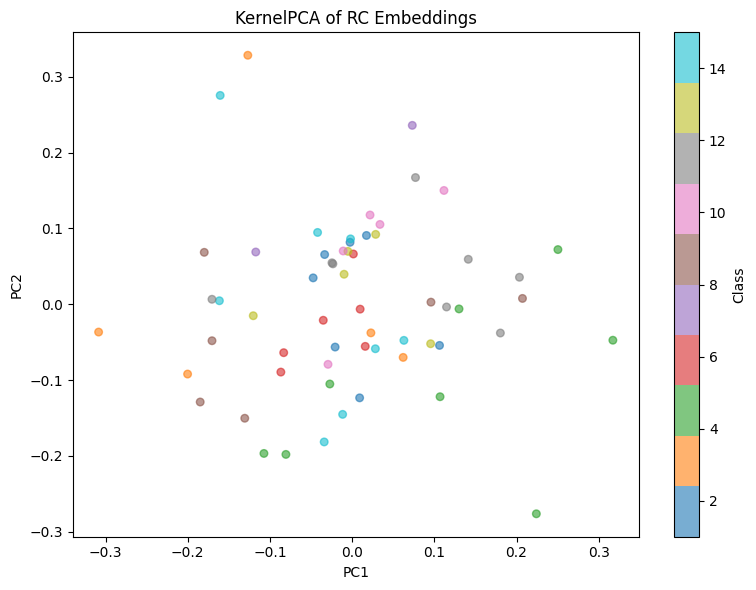

In [9]:
best_nmi_rc = 0
best_threshold_rc = 50
best_clusters_rc = None

for t in thresholds:
    clusters = fcluster(Z_rc, t=t, criterion="distance")
    nmi = v_measure_score(ytr_sub, clusters)
    if nmi > best_nmi_rc:
        best_nmi_rc = nmi
        best_threshold_rc = t
        best_clusters_rc = clusters

print(f"  Best threshold: {best_threshold_rc}, NMI: {best_nmi_rc:.3f}")
print(f"  Number of clusters found: {len(np.unique(best_clusters_rc))}")

# 7. KernelPCA
print("\n7. KernelPCA dimensionality reduction...")
kpca_rc = KernelPCA(n_components=2, kernel='rbf', gamma=0.01)
X_kpca_rc = kpca_rc.fit_transform(mts_representations)

fig = plt.figure(figsize=(8, 6))
plt.scatter(X_kpca_rc[:, 0], X_kpca_rc[:, 1], c=ytr_sub, cmap='tab10', alpha=0.6, s=30)
plt.title("KernelPCA of RC Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Class')
plt.tight_layout()

In [11]:
# =============================================================================
# Summary
# =============================================================================
print("\n" + "="*60)
print("Summary")
print("="*60)

print("\nClassification Results:")
print("-" * 60)
print(f"{'Method':<15} {'Classifier':<10} {'Accuracy':<12} {'F1-score':<12}")
print("-" * 60)
print(f"{'DTW':<15} {'SVC':<10} {svc_accuracy:<12.3f} {svc_f1:<12.3f}")
print(f"{'DTW':<15} {'k-NN':<10} {knn_accuracy:<12.3f} {knn_f1:<12.3f}")
print(f"{'TCK':<15} {'SVC':<10} {svc_tck_accuracy:<12.3f} {svc_tck_f1:<12.3f}")
print(f"{'TCK':<15} {'k-NN':<10} {knn_tck_accuracy:<12.3f} {knn_tck_f1:<12.3f}")
print(f"{'RC-embedding':<15} {'SVC':<10} {svc_rc_accuracy:<12.3f} {svc_rc_f1:<12.3f}")
print(f"{'RC-embedding':<15} {'k-NN':<10} {knn_rc_accuracy:<12.3f} {knn_rc_f1:<12.3f}")

print("\nClustering Results (NMI):")
print("-" * 60)
print(f"{'DTW':<15} NMI: {best_nmi:.3f} (threshold={best_threshold})")
print(f"{'TCK':<15} NMI: {best_nmi_tck:.3f} (threshold={best_threshold_tck})")
print(f"{'RC-embedding':<15} NMI: {best_nmi_rc:.3f} (threshold={best_threshold_rc})")


Summary

Classification Results:
------------------------------------------------------------
Method          Classifier Accuracy     F1-score    
------------------------------------------------------------
DTW             SVC        0.033        0.004       
DTW             k-NN       0.667        0.635       
TCK             SVC        0.133        0.131       
TCK             k-NN       0.100        0.024       
RC-embedding    SVC        0.033        0.015       
RC-embedding    k-NN       0.033        0.015       

Clustering Results (NMI):
------------------------------------------------------------
DTW             NMI: 0.797 (threshold=10)
TCK             NMI: 0.000 (threshold=50)
RC-embedding    NMI: 0.378 (threshold=10)
